# **UTS Eksplorasi dan Visualisasi Data**

Nama = Mareko Famaogombowo Nazara <br>
NIM = 20254920001<br>
Mata Kuliah = Ekplorasi dan Visualisasi Data

### Variabel-variabel dalam Dataset:

1. **MedInc (Median Income)**
   - Pendapatan median per blok (dalam puluhan ribu dolar)
   - Rata-rata dari pendapatan rumah tangga di daerah tertentu
   - Unit: $10,000 (misal: 3.0 = $30,000)

2. **HouseAge (House Age)**
   - Usia rata-rata rumah-rumah di blok tersebut
   - Unit: Tahun

3. **AveRooms (Average Rooms)**
   - Rata-rata jumlah ruangan di rumah-rumah di blok tersebut
   - Per household dalam census block

4. **AveBedrms (Average Bedrooms)**
   - Rata-rata jumlah kamar tidur di rumah-rumah di blok tersebut
   - Per household dalam census block

5. **Population**
   - Jumlah penduduk yang tinggal di blok tersebut
   - Total populasi dalam census block

6. **AveOccup (Average Occupancy)**
   - Jumlah rata-rata penghuni per rumah di blok tersebut
   - Dihitung: Population / Jumlah Households

7. **Latitude**
   - Garis lintang lokasi blok
   - Unit: Derajat (°)

8. **Longitude**
   - Garis bujur lokasi blok
   - Unit: Derajat (°)

9. **MedHouseVal (Median House Value)** - *VARIABEL TARGET*
   - Nilai median rumah di blok tersebut
   - Unit: $100,000 (ratusan ribu dolar)
   - Misal: 2.5 = $250,000

---

## **SOAL 1**
a. Jelaskan secara rinci apa yang dimaksud dengan Eksplorasi Data Analysis (EDA)!<br>
b. Mengapa penting untuk melakukan EDA sebelum melakukan analisis yang lebih lanjut?<br>
c. Pada California Housing Dataset variabel mana yang kemungkinan bisa dilakukan analisis distribusi
data, analisis korelasi, dan analisis regresi?<br>
d. Jelaskan kenapa variabel Lattitude dan Longitude tidak dimasukkan pada analisis distribusi data, analisis
korelasi, dan analisis regresi!

## Jawaban:

**a. Apa itu Exploratory Data Analysis (EDA)?** <br>
EDA adalah proses memahami, meringkas, dan memvisualisasikan karakteristik utama dataset sebelum melakukan pemodelan formal. Diperkenalkan John W. Tukey (1977), EDA mencakup:
- **Pemeriksaan struktur data** — jumlah baris/kolom, tipe data, preview awal
- **Deteksi missing values** — identifikasi data kosong dan strategi penanganannya
- **Deteksi outlier** — nilai ekstrem via boxplot, z-score, atau IQR
- **Analisis distribusi** — histogram, density plot untuk memahami sebaran tiap variabel
- **Analisis korelasi** — heatmap korelasi antar variabel
- **Visualisasi data** — scatter plot, bar chart, pairplot untuk mengungkap pola tersembunyi

**b. Mengapa EDA Penting Sebelum Analisis Lanjutan?** <br>
EDA bersifat krusial karena mencegah prinsip "Garbage In, Garbage Out":

- **Mencegah bias model** — data kotor menghasilkan output tidak valid meski model canggih
- **Mendeteksi asumsi yang dilanggar** — regresi linear butuh distribusi relatif normal; jika data sangat skewed, model akan bias
- **Memandu feature engineering** — menentukan variabel mana yang perlu transformasi (log, scaling) atau dihilangkan
- **Efisiensi komputasi** — membuang fitur tidak relevan sebelum pelatihan model
- **Komunikasi awal** — hasil EDA menjadi laporan awal kepada stakeholder sebelum masuk ke modeling

| Jenis Analisis | Variabel yang Direkomendasikan | Keterangan |
|---|---|---|
| **Distribusi Data** | Semua 9 variabel (`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, `Longitude`, `MedHouseVal`) | Semua variabel bertipe numerik sehingga dapat dianalisis distribusinya |
| **Korelasi** | Semua 9 variabel | Prioritaskan pasangan `MedInc ↔ MedHouseVal` (korelasi terkuat) dan waspadai `AveRooms ↔ AveBedrms` (multikolinearitas tinggi) |
| **Regresi** | **Y:** `MedHouseVal` — **X:** `MedInc`, `HouseAge`, `AveRooms`, `Latitude`, `Longitude` | Hindari memasukkan `AveBedrms` bersama `AveRooms`; `Population` dan `AveOccup` perlu penanganan outlier terlebih dahulu |

**d. Mengapa Latitude & Longitude Dikecualikan?** <br>
Ada 4 alasan utama (detail tersedia di tab "Latitude & Longitude" pada dashboard):
1. Multikolinearitas Ekstrem (r = −0.925) — California membentang diagonal NW ke SE, membuat Lat & Long berkorelasi hampir sempurna. Memasukkan keduanya sekaligus merusak estimasi koefisien regresi secara fundamental.
2. Distribusi Uniform — Tidak Bermakna Statistik — Nilainya hanya mencerminkan batas geografis California (bukan fenomena sosial-ekonomi), sehingga histogram-nya datar dan tidak informatif untuk analisis distribusi.
3. Hubungan Non-Linear dengan Harga — Pengaruh lokasi terhadap harga bersifat spatial non-linear (pantai vs pedalaman, kota vs desa). Regresi linear tidak bisa menangkap pola ini dari koordinat mentah — diperlukan metode khusus seperti Geographically Weighted Regression (GWR).
4. Tidak Bermakna Secara Kausal — Bukan koordinat yang menyebabkan harga tinggi, melainkan fasilitas, aksesibilitas, dan karakteristik wilayah. Koordinat mentah adalah proxy tanpa interpretasi yang jelas.

## **SOAL 2:**
Lakukan  visualisasi  data  numerik  dari  dataset  California  Housing.  Gunakan  histogram  untuk  menampilkan distribusi dari variabel-variabel numerik, dan jelaskan apa yang bisa diambil dari visualisasi tersebut.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [3]:
data = pd.read_excel(r"C:\Users\Mareko\OneDrive\Documents\Python Statistika\DataSets\california_housing.xlsx")
print(data.head(101))

     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0    8.3252        41  6.984127   1.023810         322  2.555556     37.88   
1    8.3014        21  6.238137   0.971880        2401  2.109842     37.86   
2    7.2574        52  8.288136   1.073446         496  2.802260     37.85   
3    5.6431        52  5.817352   1.073059         558  2.547945     37.85   
4    3.8462        52  6.281853   1.081081         565  2.181467     37.85   
..      ...       ...       ...        ...         ...       ...       ...   
96   2.8345        31  3.894915   1.127966        2048  1.735593     37.82   
97   2.0062        29  3.681319   1.175824         202  2.219780     37.81   
98   1.2185        22  2.945600   1.016000        2024  1.619200     37.82   
99   2.6104        37  3.707143   1.107143        1838  1.875510     37.82   
100  2.4912        29  3.724800   1.131200        2304  1.843200     37.81   

     Longitude  MedHouseVal  
0      -122.23        4.526  
1  

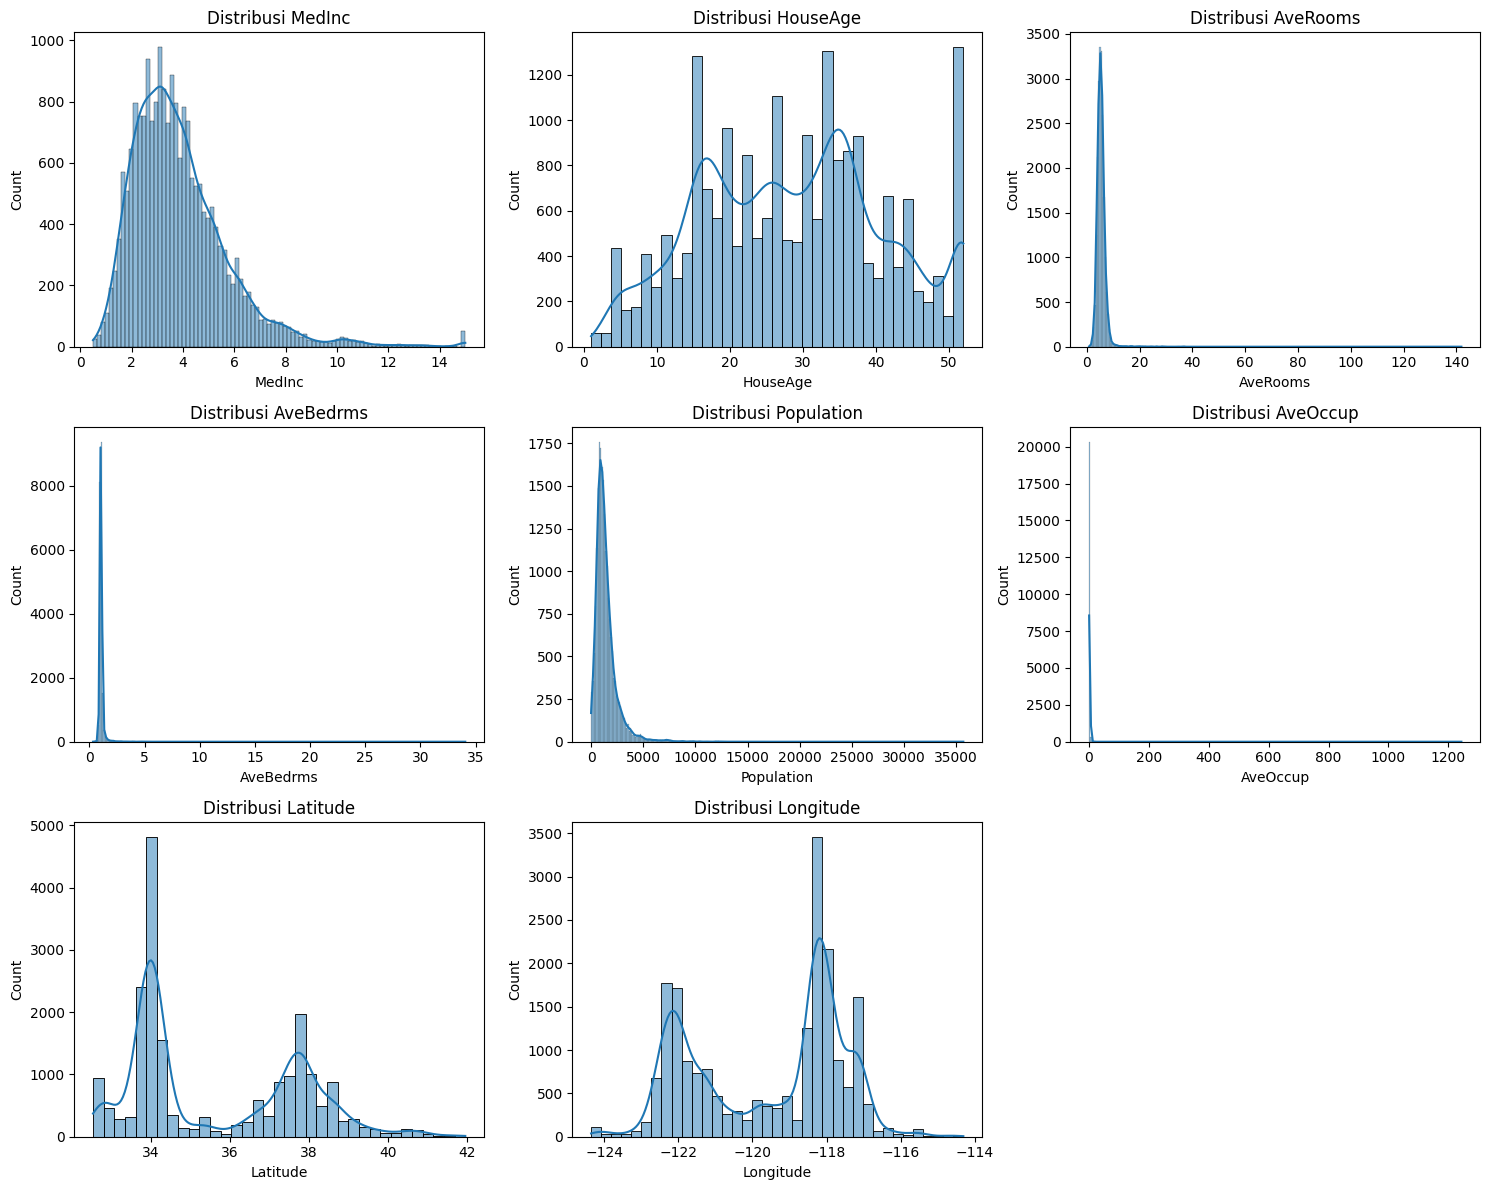

In [4]:
kolom = data.columns[:-1]
n = len(kolom)

# Hitung jumlah baris dan kolom grid secara otomatis
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(kolom):
    sns.histplot(data[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribusi {col}')

# Sembunyikan subplot kosong (jika jumlah kolom tidak habis dibagi ncols)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## INTERPRETASI SOAL 2: Analisis Visualisasi Distribusi Dataset California Housing

### Informasi Variabel yang Diberikan:
- **MedInc (Median Income)** - Pendapatan median per blok (dalam puluhan ribu dolar)
- **HouseAge (House Age)** - Usia rata-rata rumah di blok tersebut (dalam tahun)
- **AveRooms (Average Rooms)** - Rata-rata jumlah ruangan di rumah-rumah di blok tersebut
- **AveBedrms (Average Bedrooms)** - Rata-rata jumlah kamar tidur di rumah-rumah di blok tersebut
- **Population** - Jumlah penduduk yang tinggal di blok tersebut
- **AveOccup (Average Occupancy)** - Jumlah rata-rata penghuni per rumah di blok tersebut
- **Latitude** - Garis lintang lokasi blok (dalam derajat)
- **Longitude** - Garis bujur lokasi blok (dalam derajat)

### Kode yang Digunakan:
```python
for i, col in enumerate(kolom):
    sns.histplot(data[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribusi {col}')

# Sembunyikan subplot kosong (jika jumlah kolom tidak habis dibagi ncols)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
```

### Analisis Visualisasi per Variabel:

#### 1. **Distribusi MedInc (Median Income)**
- **Bentuk Distribusi:** Right-skewed (miring ke kanan)
- **Karakteristik:**
  - Puncak distribusi berada di rentang 2-3
  - Mayoritas data terkonsentrasi di nilai rendah hingga sedang
  - Terdapat ekor panjang ke kanan hingga nilai ~15
  - Kurva KDE menunjukkan distribusi yang relatif smooth
- **Interpretasi:** 
  - Sebagian besar blok memiliki median income yang relatif rendah hingga sedang
  - Ada variasi yang cukup besar dalam pendapatan median antar blok
  - Beberapa blok memiliki pendapatan median yang sangat tinggi (outliers di sisi kanan)

#### 2. **Distribusi HouseAge (Usia Rumah)**
- **Bentuk Distribusi:** Mendekati uniform (seragam) dengan spike di ujung kanan
- **Karakteristik:**
  - Distribusi relatif merata dari 0 hingga ~50 tahun
  - Terdapat spike (lonjakan) yang sangat tinggi di nilai maksimum (~52 tahun)
  - Tidak ada pola miring yang jelas
- **Interpretasi:**
  - Dataset mencakup rumah dari berbagai usia secara merata
  - Spike di nilai maksimum mengindikasikan kemungkinan **data censoring** (semua rumah yang lebih tua dari nilai tertentu dikelompokkan ke nilai maksimum)
  - Tidak ada dominasi rumah baru atau rumah lama secara khusus

#### 3. **Distribusi AveRooms (Rata-rata Jumlah Kamar)**
- **Bentuk Distribusi:** Heavily right-skewed dengan outliers ekstrem
- **Karakteristik:**
  - Mayoritas data terkonsentrasi di rentang 4-7 ruangan
  - Terdapat ekor yang sangat panjang mencapai >100 ruangan
  - Puncak distribusi berada di sekitar 5-6 ruangan
- **Interpretasi:**
  - Sebagian besar blok memiliki rata-rata 4-7 ruangan per rumah
  - Terdapat outliers yang sangat ekstrem (>50 ruangan)
  - Outliers ini kemungkinan merupakan:
    - Anomali data atau kesalahan pencatatan
    - Blok dengan karakteristik unik (sangat sedikit rumah dengan total ruangan banyak)
  - **Rekomendasi:** Perlu dilakukan pengecekan dan penanganan outliers

#### 4. **Distribusi AveBedrms (Rata-rata Jumlah Kamar Tidur)**
- **Bentuk Distribusi:** Sangat terkonsentrasi dengan spike tajam
- **Karakteristik:**
  - Spike sangat tinggi di rentang 0.5-1.5 kamar tidur
  - Mayoritas data berada di bawah 2 kamar tidur
  - Terdapat outliers mencapai >30 kamar tidur
- **Interpretasi:**
  - Distribusi sangat terkonsentrasi di nilai rendah
  - Nilai rata-rata ~1 kemungkinan menunjukkan bahwa kebanyakan rumah memiliki 1-2 kamar tidur
  - Outliers ekstrem perlu diinvestigasi lebih lanjut
  - **Catatan:** Variabel ini harus dianalisis bersama dengan AveRooms untuk memahami rasio kamar tidur terhadap total ruangan

#### 5. **Distribusi Population (Populasi)**
- **Bentuk Distribusi:** Heavily right-skewed
- **Karakteristik:**
  - Puncak distribusi di rentang 500-1500 penduduk
  - Mayoritas blok memiliki populasi rendah hingga sedang
  - Ekor panjang mencapai >30,000 penduduk
- **Interpretasi:**
  - Sebagian besar blok memiliki populasi yang relatif kecil
  - Ada beberapa blok dengan populasi sangat tinggi (area dengan kepadatan tinggi)
  - Variasi populasi yang besar menunjukkan keragaman tipe area (residential, urban, dll)

#### 6. **Distribusi AveOccup (Rata-rata Hunian)**
- **Bentuk Distribusi:** Extremely right-skewed dengan outliers sangat ekstrem
- **Karakteristik:**
  - Puncak distribusi di rentang 2-4 penghuni per rumah
  - Mayoritas data terkonsentrasi di nilai 1-5
  - Outliers mencapai >1000 (sangat tidak wajar)
- **Interpretasi:**
  - Nilai normal berada di 2-4 penghuni per rumah
  - Outliers ekstrem (>10) sangat mencurigakan dan kemungkinan besar:
    - Kesalahan data
    - Anomali perhitungan (Population dibagi jumlah rumah yang sangat kecil)
  - **CRITICAL:** Variabel ini memerlukan data cleaning yang serius sebelum digunakan untuk modeling

#### 7. **Distribusi Latitude (Lintang)**
- **Bentuk Distribusi:** Bimodal (dua puncak)
- **Karakteristik:**
  - Puncak pertama di sekitar 34°
  - Puncak kedua di sekitar 37-38°
  - Lembah (gap) di sekitar 35-36°
  - Range: sekitar 32° hingga 42°
- **Interpretasi:**
  - Data berasal dari dua area geografis yang terpisah atau terkonsentrasi
  - Gap di tengah menunjukkan area dengan data yang lebih sedikit
  - Pola bimodal menunjukkan kemungkinan dua cluster geografis utama dalam dataset

#### 8. **Distribusi Longitude (Bujur)**
- **Bentuk Distribusi:** Bimodal
- **Karakteristik:**
  - Puncak pertama di sekitar -122°
  - Puncak kedua di sekitar -118°
  - Range: sekitar -124° hingga -114°
  - Gap kecil di sekitar -120°
- **Interpretasi:**
  - Serupa dengan Latitude, menunjukkan dua konsentrasi geografis
  - Kombinasi distribusi Latitude dan Longitude mengindikasikan data terkonsentrasi di dua area geografis yang berbeda
  - Lokasi geografis kemungkinan merupakan faktor penting dalam dataset ini

---

### KESIMPULAN SOAL 2:

#### **1. Karakteristik Umum Distribusi:**
- **Mayoritas variabel menunjukkan right-skewness** (MedInc, AveRooms, AveBedrms, Population, AveOccup)
- Hanya HouseAge yang menunjukkan distribusi mendekati uniform
- Latitude dan Longitude menunjukkan pola bimodal yang unik

#### **2. Identifikasi Outliers:**

**Variabel dengan Outliers Ekstrem (Perlu Penanganan Urgent):**
- 🚨 **AveOccup:** Outliers >10 sangat mencurigakan, kemungkinan besar data error
- 🚨 **AveRooms:** Outliers >50 tidak masuk akal untuk rumah normal
- ⚠️ **AveBedrms:** Outliers >10 perlu diverifikasi

**Variabel dengan Outliers Wajar:**
- ✅ **Population:** Outliers hingga 30,000+ masih bisa diterima (area urban padat)
- ✅ **MedInc:** Outliers di sisi kanan menunjukkan area dengan income tinggi (wajar)

#### **3. Kualitas Data:**

**Data Berkualitas Baik:**
- MedInc: Distribusi natural dan masuk akal
- HouseAge: Pola jelas dengan censoring yang dapat dipahami
- Latitude & Longitude: Menunjukkan pola geografis yang konsisten

**Data yang Memerlukan Cleaning:**
- AveOccup: Wajib dilakukan filtering outliers
- AveRooms: Perlu investigasi dan filtering
- AveBedrms: Perlu validasi terhadap outliers

#### **4. Insight Geografis:**
- **Pola Bimodal** pada Latitude dan Longitude menunjukkan data terkonsentrasi di **dua area geografis berbeda**
- Gap di tengah distribusi geografis menunjukkan area dengan representasi data lebih sedikit
- Lokasi geografis (koordinat) kemungkinan menjadi **prediktor penting** dalam analisis selanjutnya

#### **5. Hubungan Antar Variabel (Hipotesis untuk Validasi):**
- **AveBedrms vs AveRooms:** Perlu dicek rasionya (normalnya kamar tidur adalah sebagian dari total ruangan)
- **Population vs AveOccup:** Konsistensi perlu diverifikasi (AveOccup = Population / Jumlah Rumah)
- **MedInc vs Lokasi:** Kemungkinan ada korelasi antara income dengan area geografis tertentu

#### **6. Rekomendasi Preprocessing:**

**a. Outlier Handling (Prioritas Tinggi):**
```python
# Identifikasi outliers ekstrem
# Untuk AveOccup
threshold_occup = 10  # nilai di atas ini perlu diinvestigasi

# Untuk AveRooms
threshold_rooms = 20  # nilai di atas ini mencurigakan

# Untuk AveBedrms
threshold_bedrms = 5  # nilai di atas ini perlu validasi
```

**b. Transformasi untuk Variabel Skewed:**
- Pertimbangkan log transformation untuk: MedInc, Population, AveOccup (setelah cleaning)
- Scaling diperlukan karena variabel memiliki skala yang sangat berbeda

**c. Feature Engineering Potensial:**
- Ratio: AveBedrms / AveRooms (proporsi kamar tidur)
- Density: Population / AveRooms (kepadatan relatif)
- Geographic clustering berdasarkan Latitude & Longitude

#### **7. Implikasi untuk Analisis Selanjutnya:**

**Untuk Exploratory Data Analysis:**
- Perlu dibuat **correlation matrix** untuk melihat hubungan antar variabel
- **Scatter plots** untuk melihat hubungan bivariat, terutama dengan variabel target
- **Geographic visualization** (heatmap berdasarkan koordinat) untuk memahami pola spasial

**Untuk Modeling:**
- Outliers harus ditangani sebelum modeling (terutama untuk algoritma yang sensitif terhadap outliers)
- Feature scaling wajib dilakukan karena perbedaan skala yang besar
- Pertimbangkan importance lokasi geografis dalam model
- Variabel dengan distribusi skewed mungkin perlu transformasi untuk algoritma tertentu (misal: linear regression)

#### **8. Pertanyaan untuk Investigasi Lebih Lanjut:**
1. Apakah outliers di AveOccup, AveRooms, AveBedrms adalah data error atau memiliki makna khusus?
2. Mengapa terdapat gap di distribusi Latitude dan Longitude? Apa karakteristik area di gap tersebut?
3. Bagaimana hubungan antara MedInc dengan lokasi geografis (bimodal pattern)?
4. Apakah ada variabel target (misalnya harga rumah) yang akan diprediksi? Bagaimana korelasinya dengan variabel-variabel ini?

#### **9. Keunggulan Visualisasi dengan KDE:**
- **Histogram + KDE** memberikan dua perspektif:
  - Histogram: Menunjukkan frekuensi aktual data
  - KDE: Memberikan estimasi smooth dari underlying distribution
- Kombinasi ini membantu mengidentifikasi:
  - Modality (unimodal, bimodal, multimodal)
  - Skewness dan kurtosis
  - Presence of outliers
- Lebih informatif dibanding histogram atau density plot sendiri

#### **10. Red Flags yang Harus Segera Ditangani:**
- ⛔ **AveOccup > 10:** Sangat mencurigakan, perlu investigasi/removal
- ⚠️ **AveRooms > 50:** Kemungkinan besar error
- ⚠️ **AveBedrms > 5:** Validasi apakah masuk akal jika dibandingkan dengan AveRooms
- ℹ️ **Consistency check:** Apakah AveBedrms < AveRooms untuk semua observasi? (harus ya)

---

## **SOAL 3:** 
Tampilkan korelasi antar variabel numerik dalam dataset California Housing. Identifikasi variabel mana yang 
memiliki korelasi tertinggi dan terendah, dan jelaskan interpretasinya.

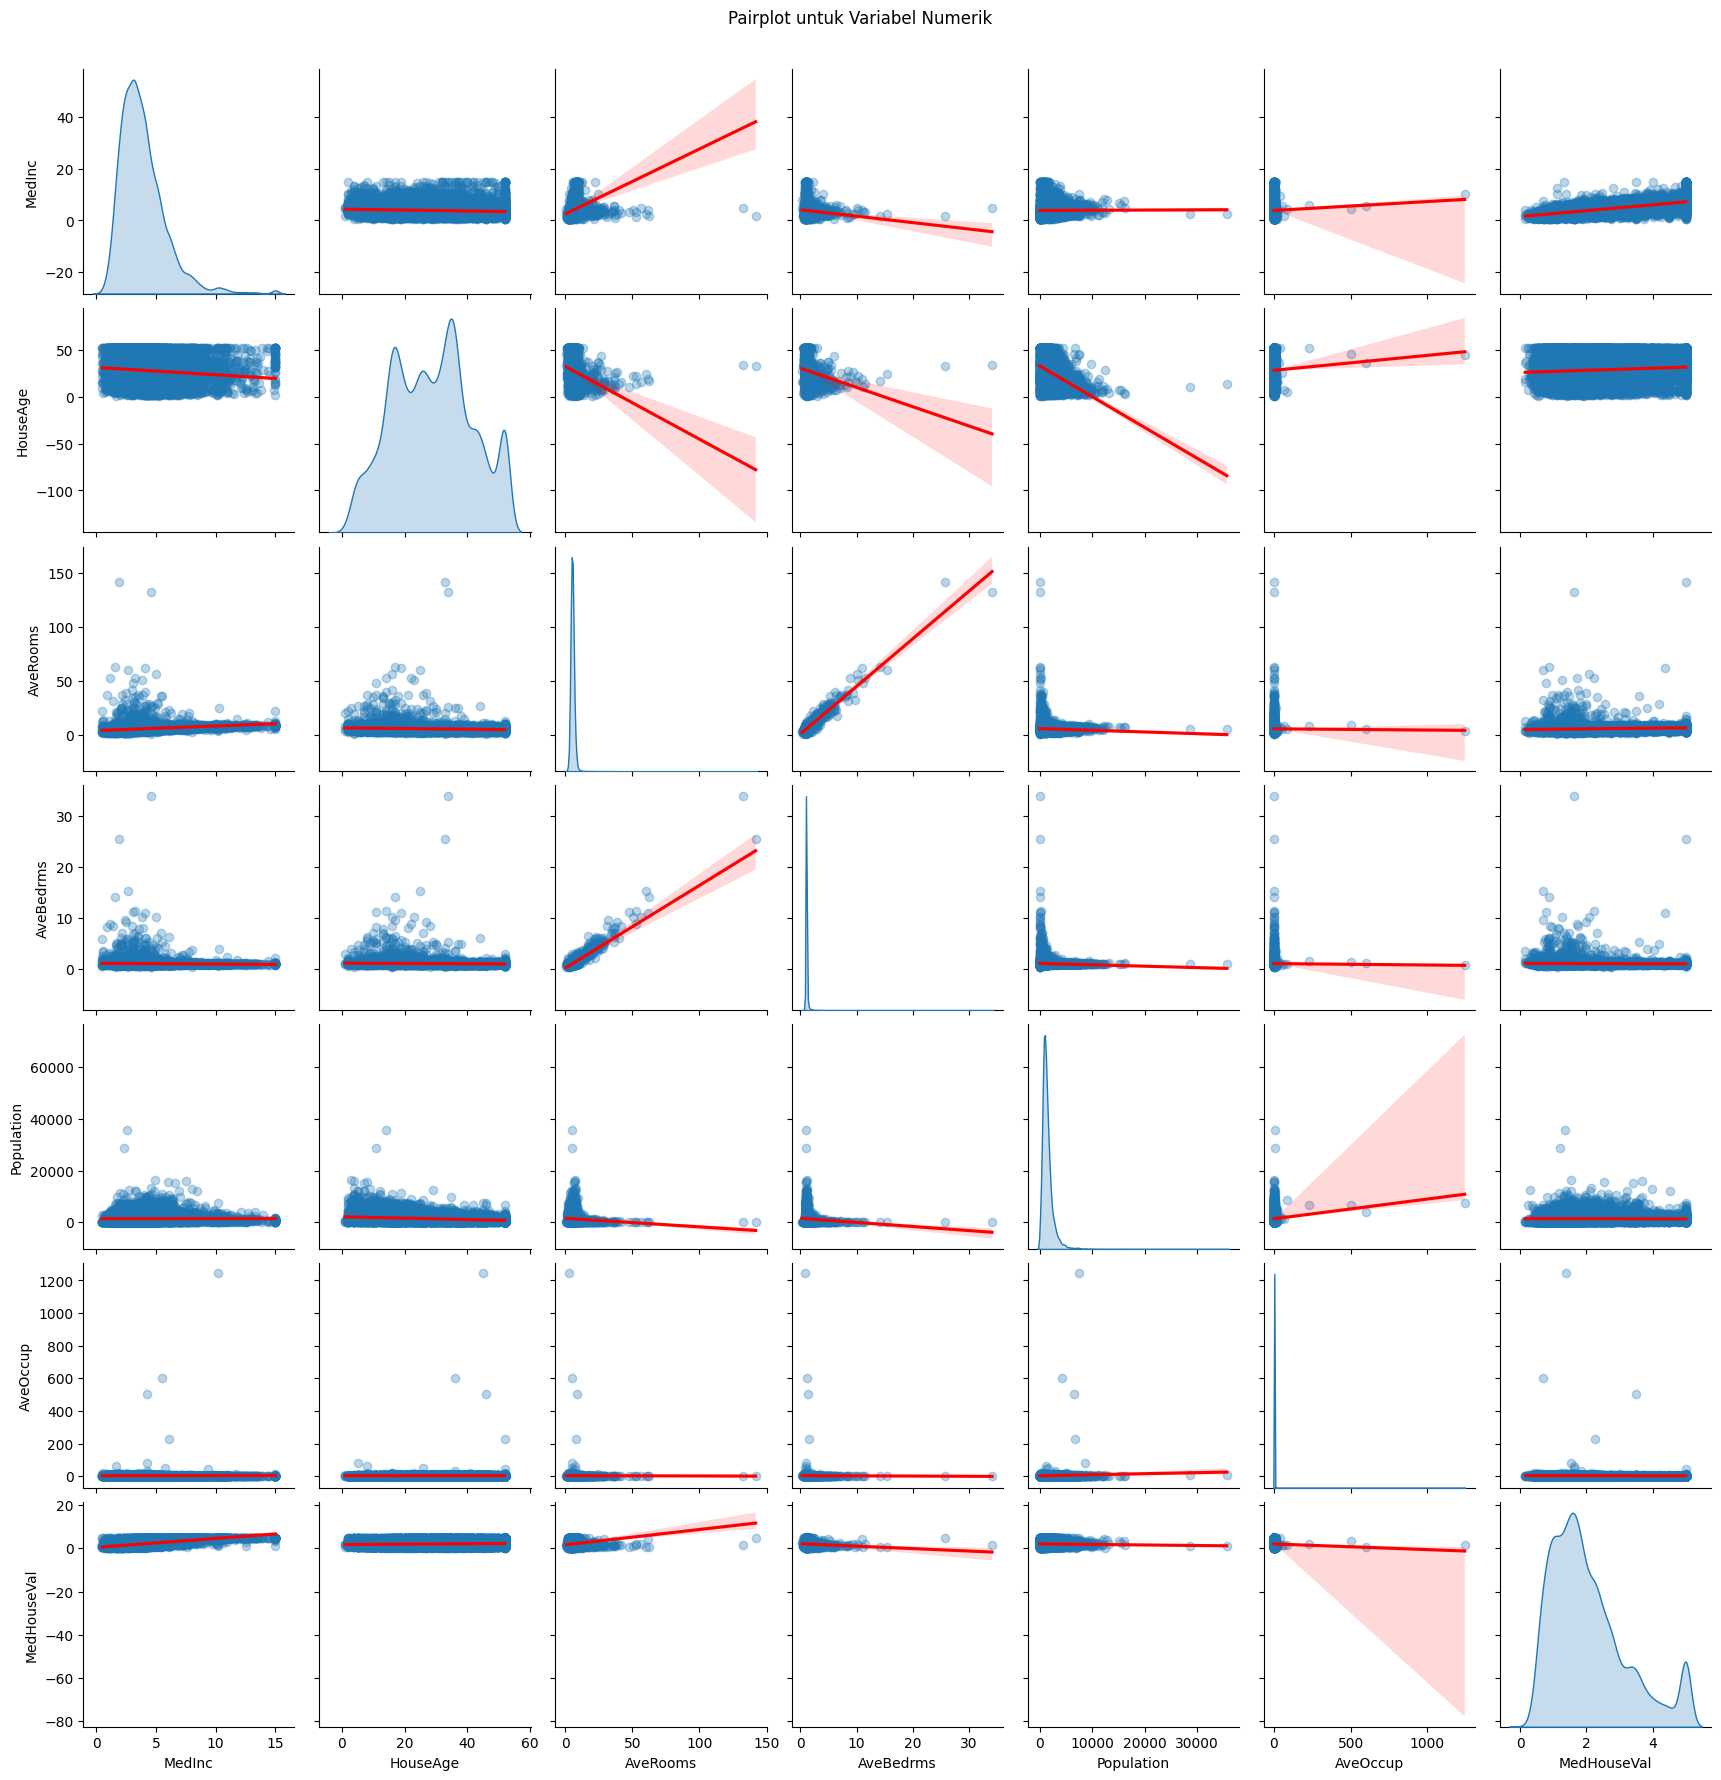

In [5]:
# Pilih kolom relevan (tanpa Latitude & Longitude)
kolom_relevan = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
    'Population', 'AveOccup', 'MedHouseVal'
]

# Simpan hasil pairplot ke variabel 'g'
g = sns.pairplot(
    data[kolom_relevan],
    diag_kind='kde',        # diagonal: kurva distribusi
    kind='reg',       # off-diagonal: scatter plot
    plot_kws={
        'scatter_kws' :{'alpha': 0.3},
        'line_kws': {'color': 'red'}
    }# titik semi-transparan agar tidak penuh
)

# Judul dipasang lewat g.fig, bukan plt
g.fig.suptitle("Pairplot untuk Variabel Numerik", y=1.02)
plt.show()

In [6]:
import numpy as np
print("Korelasi dan peringkat antar variabel:\n")
df = data.drop(columns=['Latitude', 'Longitude'])
corr_matrix = df.corr()
# Ambil semua pasangan unik (tanpa duplikat & diagonal)
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .dropna()
    .reset_index()
)
corr_pairs.columns = ['Variabel 1', 'Variabel 2', 'Korelasi']

# Urutkan berdasarkan nilai absolut
corr_pairs['Abs'] = corr_pairs['Korelasi'].abs()
corr_pairs = corr_pairs.sort_values('Abs', ascending=False).drop('Abs', axis=1)

print(corr_pairs.round(4).to_string(index=False))

Korelasi dan peringkat antar variabel:

Variabel 1  Variabel 2  Korelasi
  AveRooms   AveBedrms    0.8476
    MedInc MedHouseVal    0.6881
    MedInc    AveRooms    0.3269
  HouseAge  Population   -0.2962
  HouseAge    AveRooms   -0.1533
  AveRooms MedHouseVal    0.1519
    MedInc    HouseAge   -0.1190
  HouseAge MedHouseVal    0.1056
  HouseAge   AveBedrms   -0.0777
  AveRooms  Population   -0.0722
Population    AveOccup    0.0699
 AveBedrms  Population   -0.0662
    MedInc   AveBedrms   -0.0620
 AveBedrms MedHouseVal   -0.0467
Population MedHouseVal   -0.0246
  AveOccup MedHouseVal   -0.0237
    MedInc    AveOccup    0.0188
  HouseAge    AveOccup    0.0132
 AveBedrms    AveOccup   -0.0062
  AveRooms    AveOccup   -0.0049
    MedInc  Population    0.0048


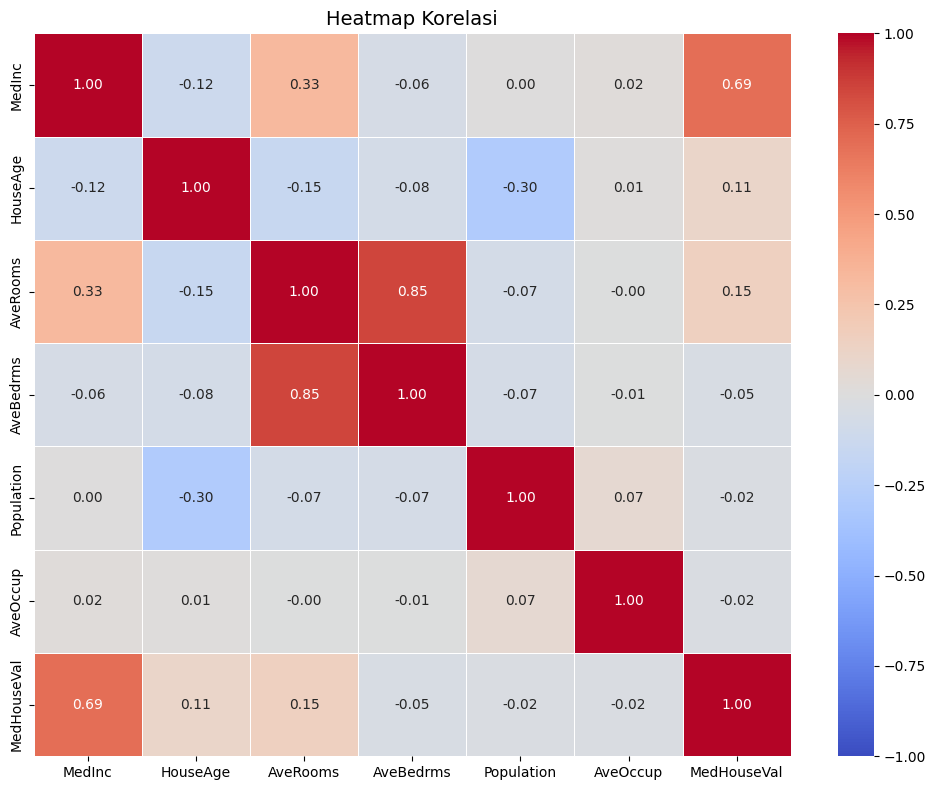

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # tampilkan angka
    fmt='.2f',           # 2 desimal
    cmap='coolwarm',     # merah=positif, biru=negatif
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Heatmap Korelasi', fontsize=14)
plt.tight_layout()
plt.show()

## Tabel Interpretasi Soal Nomor 3: 

| Pasangan Variabel | Arah Korelasi | Kekuatan | Keterangan |
| :--- | :---: | :--- | :--- |
| AveRooms ↔ AveBedrms | Positif | Sangat Kuat | Korelasi tertinggi |
| MedInc ↔ MedHouseVal | Positif | Kuat | Prediktor terbaik target |
| HouseAge ↔ AveRooms | Negatif | Sedang | Rumah tua = lebih sedikit ruang |
| AveOccup ↔ MedHouseVal | Negatif | Lemah | Terdistorsi outlier |
| Population ↔ MedInc | Hampir Nol | Sangat Lemah | Korelasi terendah |
 

## **SOAL 4:** 
Lakukan  Analisis  Regresi  Berganda  dan  gunakan  variabel  MedInc  sebagai  variabel  dependen.  Berikan 
penjelasan mengenai nilai R-squared dan variabel mana yang paling berpengaruh terhadap variabel dependen.

Mean Squared Error: 1.13
Root Mean Squared Error: 1.06
R-squared: 0.68


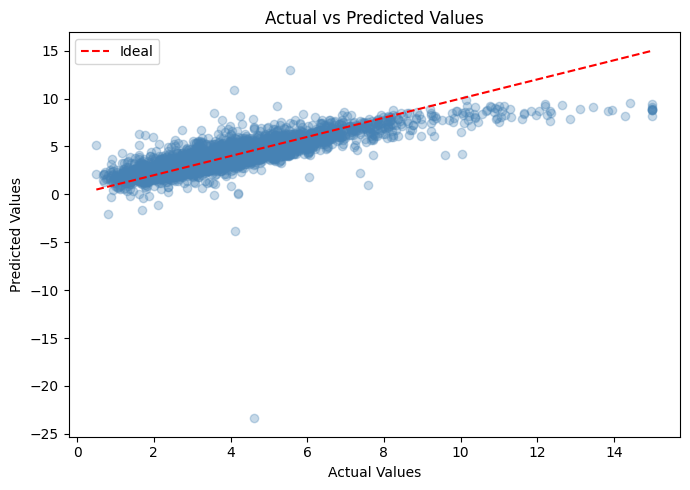

In [8]:
X = data[['MedHouseVal', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']]
Y = data['MedInc']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared: {r2:.2f}')

koef = pd.DataFrame(
    {
        'Feature': X.columns,
        'Coefficient': model.coef_
    }
)

plt.figure(figsize=(7, 5))
plt.scatter(Y_test, Y_pred, alpha=0.3, color='steelblue')
plt.plot(
    [Y.min(), Y.max()],
    [Y.min(), Y.max()],
    color='red',
    linewidth=1.5,
    label='Ideal',
    linestyle='--'
)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Korelasi Pearson antara setiap fitur dan MedInc
corrs = data[['MedHouseVal', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedInc']].corr()
print('Korelasi Pearson antara fitur dan MedInc:')
print(corrs['MedInc'].drop('MedInc').sort_values(ascending=False).round(3))

Korelasi Pearson antara fitur dan MedInc:
MedHouseVal    0.688
AveRooms       0.327
AveOccup       0.019
Population     0.005
AveBedrms     -0.062
HouseAge      -0.119
Name: MedInc, dtype: float64


## **Interpretasi Actual vs Predicted Values**

### 1. Metrik Evaluasi Model
- **MSE (Mean Squared Error):** Menunjukkan rata-rata kuadrat selisih antara nilai aktual dan prediksi. Semakin kecil nilainya, semakin baik model. Nilai MSE yang besar menandakan prediksi model masih cukup meleset.
- **RMSE (Root Mean Squared Error):** Akar dari MSE, satuannya sama dengan target (MedInc). RMSE memudahkan interpretasi seberapa jauh rata-rata prediksi meleset dari nilai sebenarnya. Misal, RMSE = 0.80 berarti rata-rata prediksi meleset sekitar $8.000 (karena satuan MedInc adalah puluhan ribu dolar).
- **R² (R-squared):** Proporsi variasi variabel dependen (MedInc) yang bisa dijelaskan oleh model. R² = 0.68 berarti model menjelaskan 68% variasi MedInc, sisanya dipengaruhi faktor lain di luar model.

### 2. Membaca Grafik Actual vs Predicted
- **Garis merah putus-putus** adalah garis ideal (prediksi = aktual). Semakin dekat titik-titik biru ke garis ini, semakin baik prediksi model.
- **Sebaran titik** yang jauh dari garis merah menunjukkan prediksi model masih kurang presisi.
- **Pola sebaran**: Jika banyak titik di bawah garis, model cenderung underpredict (meremehkan nilai aktual). Jika di atas, model overpredict.

### 3. Pola yang Terlihat di Grafik
- **Sebaran lebar**: Titik-titik menyebar cukup jauh dari garis ideal, menandakan error prediksi masih besar.
- **Dinding vertikal** di nilai aktual tinggi: Ada batas atas pada MedInc (misal, data di-cap pada nilai maksimum), sehingga model kesulitan memprediksi nilai tinggi.
- **Outlier**: Titik-titik yang sangat jauh dari garis ideal bisa jadi akibat data outlier atau anomali.

### 4. Kesimpulan
- Model regresi sudah menangkap sebagian besar pola hubungan antara fitur dan MedInc, namun masih ada ruang perbaikan.
- Nilai R² yang cukup baik (0.68) menandakan model mampu menjelaskan sebagian besar variasi MedInc, namun masih ada 32% variasi yang belum tertangkap model (mungkin karena fitur penting lain atau hubungan non-linear).
- Perlu dilakukan analisis lebih lanjut, seperti penanganan outlier, transformasi fitur, atau mencoba model non-linear untuk meningkatkan performa prediksi.

## **SOAL 5:** 
1. Jelaskan, apakah Anda dapat mengaplikasikan konsep Analisis Time Series pada data California 
Housing? 
2. Jelaskan konsep-konsep penting tren, musiman, dan noise dalam analisis time series!

#### Jawaban:

1. Menurut saya dataset yang diberikan yaitu california housing.xlsx itu tidak bisa kita gunakan konsep time series, dikarenakan hanya dari satu titik timeline dan bukan waktu ke waktu. Lalu, sangat jelas dalam dataset tidak ada kolom yang menyatakan waktu seperti tanggal, bulan, tahun, hari atau periode yang merekam perubahan antar waktu.

2. Konsep Penting dalam Time Series

- Tren : Yaitu Pergerakan jangka panjang data secara naik atau turun secara konsisten.
- Musiman : Yaitu pola yang berulang secara periodik dalam suatu interval. 
- Noise : adalah fluktuasi acak atau tidak ada pola yang jelas, jadi tidak bisa dijelaskan oleh tren maupun musiman.